<a href="https://colab.research.google.com/github/Cheetah-lhp/MachineLearning/blob/main/KHDL_Data_Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# THỰC HÀNH: KHAI PHÁ DỮ LIỆU / PRACTICE: DATA EXPLORATION

## Tổng quan / Overview

**Khai phá dữ liệu / Data Exploration** là bước quan trọng nhất trong quy trình khoa học dữ liệu, giúp chúng ta hiểu sâu về cấu trúc, đặc điểm và mối quan hệ trong dữ liệu trước khi xây dựng mô hình machine learning.  
*Data exploration is the most important step in the data science workflow, helping us understand the structure, characteristics, and relationships in the data before building machine learning models.*  

Notebook này sẽ hướng dẫn bạn thực hiện Khai phá dữ liệu hoàn chỉnh trên bộ dữ liệu y tế về phản ứng của bệnh nhân với các loại thuốc khác nhau, sử dụng các thư viện **pandas**, **seaborn** và **matplotlib**.  
*This notebook will guide you through complete data exploration on a medical dataset about patients' responses to different drugs, using **pandas**, **seaborn**, and **matplotlib** libraries.*  

Chúng ta sẽ phân tích một bộ dữ liệu thực tế để dự đoán loại thuốc phù hợp cho từng bệnh nhân dựa trên các đặc điểm như tuổi, giới tính, huyết áp và cholesterol.  
*We will analyze a real dataset to predict the suitable drug for each patient based on features like age, gender, blood pressure, and cholesterol.*

---
## Mục tiêu Học tập / Learning Objectives

Sau khi hoàn thành notebook này, bạn sẽ có thể:  
*After completing this notebook, you will be able to:*  

- **Hiểu bản chất của khai phá dữ liệu và vai trò của nó trong quy trình Data Science / Understand the essence of data exploration and its role in the Data Science workflow**  
- **Thực hiện phân tích thống kê mô tả để nắm bắt đặc điểm cơ bản của dữ liệu / Perform descriptive statistical analysis to grasp the basic characteristics of the data**  
- **Sử dụng thành thạo pandas cho việc khai phá dữ liệu và thống kê dữ liệu / Use pandas effectively for data exploration and statistical analysis**  
- **Tạo các biểu đồ trực quan hóa bằng seaborn và matplotlib / Create visualization plots using seaborn and matplotlib**  
- **Phân tích mối quan hệ giữa các biến số và biến phân loại / Analyze relationships between numerical and categorical variables**  
- **Phát hiện insights quan trọng từ dữ liệu để hỗ trợ modeling / Discover important insights from the data to support modeling**  
- **Diễn giải kết quả một cách chính xác và có ý nghĩa thực tiễn / Interpret results accurately and meaningfully for practical applications**

---

### Kỹ năng cụ thể / Specific Skills

- **Thống kê mô tả: Mean, median, mode, standard deviation, quartiles / Descriptive statistics: mean, median, mode, standard deviation, quartiles**  
- **Phân tích phân phối: Histogram, density plots, boxplots / Distribution analysis: histograms, density plots, boxplots**  
- **Phân tích tương quan: Correlation matrix, scatter plots / Correlation analysis: correlation matrices, scatter plots**  
- **Phân tích nhóm: Group-by operations, cross-tabulation / Group analysis: group-by operations, cross-tabulations**  
- **Trực quan hóa nâng cao: Heatmaps, pair plots, categorical plots / Advanced visualization: heatmaps, pair plots, categorical plots**

> **Lưu ý / Note**: Khai phá dữ liệu không chỉ là vẽ biểu đồ mà quan trọng hơn là **diễn giải và rút ra insights từ những gì quan sát được / Data exploration is not just about plotting charts; more importantly, it is about interpreting and extracting insights from what is observed.**


## Hướng dẫn Cài đặt Môi trường / Environment Setup

### Thư viện cần thiết / Required Libraries

Để thực hiện khai phá dữ liệu, chúng ta cần các thư viện Python sau:  
*To perform data exploration, we need the following Python libraries:*

| Thư viện / Library | Mục đích sử dụng / Purpose | Vai trò trong Khai phá dữ liệu / Role in Data Exploration |
|-------------------|---------------------------|----------------------------------------------------------|
| **pandas** | Xử lý và thao tác dữ liệu / Data manipulation and handling | Đọc dữ liệu, thống kê mô tả, group operations / Reading data, descriptive statistics, group operations |
| **numpy** | Tính toán số học / Numerical computations | Các phép toán mảng, thống kê toán học / Array operations, mathematical statistics |
| **matplotlib** | Trực quan hóa cơ bản / Basic visualization | Tạo biểu đồ line, bar, scatter plots / Create line, bar, scatter plots |
| **seaborn** | Trực quan hóa nâng cao / Advanced visualization | Biểu đồ thống kê đẹp, heatmaps, distribution plots / Beautiful statistical plots, heatmaps, distribution plots |
| **scipy** | Thống kê nâng cao / Advanced statistics | Kiểm định thống kê, probability distributions / Statistical tests, probability distributions |
| **scikit-learn** | Machine learning | Preprocessing, model evaluation metrics / Preprocessing, evaluating machine learning models |

---

### Lệnh cài đặt / Installation Command

Chạy lệnh sau để cài đặt tất cả các thư viện cần thiết:  
*Run the following command to install all required libraries:*

```bash
pip install pandas numpy matplotlib seaborn scipy scikit-learn jupyterlab

```
### Yêu cầu hệ thống / System Requirements

- **Python 3.7+** (khuyến nghị Python 3.9+)  
  **Python 3.7+** (recommended Python 3.9+)
- **Jupyter Lab/Notebook** để chạy interactive cells  
  **Jupyter Lab/Notebook** to run interactive cells
- **Bộ nhớ RAM**: Tối thiểu 4GB (khuyến nghị 8GB+)  
  **RAM**: Minimum 4GB (recommended 8GB+)
- **Dữ liệu**: File `drug200.csv` (sẽ được tải trong notebook)  
  **Data**: `drug200.csv` file (to be loaded in the notebook)

---

### Thông tin về môi trường / Environment Notes

**Cho người dùng Google Colab / For Google Colab users:**  
- Môi trường đã được cài đặt sẵn hầu hết các thư viện  
  Most libraries are pre-installed
- Chỉ cần chạy cell cài đặt thư viện bên dưới  
  You only need to run the installation cell below
- Cần upload file dữ liệu thủ công  
  You need to upload the dataset manually

**Cho người dùng Miniconda/Anaconda / For Miniconda/Anaconda users:**  
- Tham khảo hướng dẫn cài đặt / Refer to installation guides:  
  - [Windows](https://www.youtube.com/watch?v=EBbcsjBSEi8)  
  - [MacOS](https://www.youtube.com/watch?v=WdXdl0C0jfE)  
- Tải file code / Download code files: [ML-code.zip](https://users.soict.hust.edu.vn/khoattq/ml-dm-course/ML-code.zip)


## Bước 1: Chuẩn bị Môi trường và Dữ liệu / Step 1: Environment and Data Preparation

Trước khi bắt đầu khai phá, chúng ta cần chuẩn bị đầy đủ môi trường làm việc và dữ liệu cần thiết.  
*Before starting data exploration, we need to prepare the working environment and the necessary dataset.*  

Quá trình này bao gồm:  
*This process includes:*

1. **Cài đặt các thư viện** cần thiết cho phân tích dữ liệu  
   *Installing the required libraries for data analysis*
2. **Tải xuống dataset** từ nguồn chính thức  
   *Downloading the dataset from the official source*
3. **Kiểm tra tính toàn vẹn** của dữ liệu sau khi tải  
   *Verifying the integrity of the data after download*

---

### Thông tin về Dataset / Dataset Information

- **Tên dataset / Dataset name**: `drug200.csv`  
- **Nguồn / Source**: Course Material - Machine Learning & Data Mining  
- **Kích thước / Size**: 200 records × 6 features  
- **Mục đích / Purpose**: Dự đoán loại thuốc phù hợp cho bệnh nhân  
  *Predict the suitable drug for patients*

---

**Đặc điểm dữ liệu / Data Characteristics:**

- **Dữ liệu y tế thực tế** được ẩn danh hóa  
  *Real medical data that has been anonymized*
- **Cân bằng giữa các class** (5 loại thuốc)  
  *Balanced classes (5 types of drugs)*
- **Không có missing values** (dữ liệu đã được làm sạch)  
  *No missing values (data has been cleaned)*
- **Mix của numeric và categorical features**  
  *A mix of numeric and categorical features*


**Bước 1:** Ta thực hiện tải file code phục vụ cho bài học theo nguồn dưới đây

**Step 1:** We download the code file for the lesson from the source below

====== Nguồn https://users.soict.hust.edu.vn/khoattq/ml-dm-course/ML-code.zip ======

**Bước 2:** Cài đặt thư viện

In [1]:
# Step 1.1: Install necessary libraries for Data Exploration (Bước 1.1: Cài đặt các thư viện cần thiết cho Khai phá dữ liệu)

# pandas: Handle and manipulate tabular data (pandas: Xử lý và thao tác dữ liệu dạng bảng)
# numpy: Arithmetic and statistical computations (numpy: Tính toán số học và thống kê)
# matplotlib: Basic visualization (matplotlib: Trực quan hóa cơ bản)
# seaborn: Attractive statistical visualization (seaborn: Trực quan hóa thống kê đẹp mắt)
# scipy: Advanced statistics and tests (scipy: Thống kê nâng cao và kiểm định)
# scikit-learn: Machine learning and preprocessing tools (scikit-learn: Công cụ machine learning và preprocessing)
# scikit-image: Image processing (scikit-image: Xử lý ảnh)
# jupyterlab: Interactive notebook environment (jupyterlab: Môi trường notebook tương tác)
# beautifulsoup4: Web scraping (beautifulsoup4: Trích xuất dữ liệu từ web)
# PyYAML: YAML file parsing (PyYAML: Phân tích file YAML)

!pip install pandas numpy matplotlib scipy scikit-image seaborn scikit-learn jupyterlab beautifulsoup4 PyYAML

print("All libraries installed successfully!")  # Cài đặt thành công tất cả thư viện
print("Ready to start data analysis")           # Sẵn sàng bắt đầu phân tích dữ liệu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.6 MB/s eta 0:00:00
All libraries installed successfully!
Ready to start data analysis


### Bước 1.2: Tải Dataset (Chỉ cho Google Colab)  
*Step 1.2: Load Dataset (Only for Google Colab)*

**Hướng dẫn tải dữ liệu:**  
*Instructions to load data:*

1. **Tải file dữ liệu** từ [ML-code.zip](https://users.soict.hust.edu.vn/khoattq/ml-dm-course/ML-code.zip)  
   *Download the dataset from the link above*
2. **Giải nén** và tìm file `drug200.csv` trong thư mục `data/`  
   *Extract the zip file and locate `drug200.csv` inside the `data/` folder*
3. **Upload file** bằng cách chạy cell bên dưới (chỉ cho Colab)  
   *Upload the file by running the cell below (only for Colab)*

> **Lưu ý**: Nếu bạn sử dụng Jupyter Lab/Notebook trên máy tính cá nhân, hãy đặt file `drug200.csv` trong cùng thư mục với notebook này.  
> *Note: If you use Jupyter Lab/Notebook on your local computer, place `drug200.csv` in the same folder as this notebook.*


In [2]:
# Step 1.2: Upload the dataset (only for Google Colab)
# Bước 1.2: Upload file dữ liệu (chỉ cho Google Colab)
# This cell will open a file browser to select and upload 'drug200.csv'
# Cell này sẽ tạo một file browser để bạn chọn và upload file drug200.csv

try:
    from google.colab import files  # Import files module for uploading (Import module files để upload file trên Colab)
    print("Launching file uploader...")  # Print message for uploader start (Đang khởi chạy file uploader...)
    print("Please select the file 'drug200.csv' from your computer")  # Instruction for user (Hãy chọn file 'drug200.csv' từ máy tính của bạn)

    uploaded = files.upload()  # Open file browser and upload (Mở file browser và upload file)

    if uploaded:
        print("Upload successful!")  # Confirm upload success (Upload thành công!)
        for filename in uploaded.keys():
            print(f"Uploaded file: {filename} ({len(uploaded[filename])} bytes)")  # Show uploaded file info (Hiển thị tên file và dung lượng)
    else:
        print("No file was uploaded")  # No file selected (Không có file nào được upload)

except ImportError:
    print("Detected Jupyter Lab/Notebook environment")  # Colab module not found (Phát hiện môi trường Jupyter Lab/Notebook)
    print("Ensure 'drug200.csv' is in the same folder as this notebook")  # Instruction for local Jupyter (Đảm bảo file 'drug200.csv' nằm trong cùng thư mục với notebook)
    print("No upload needed, you can continue to the next step")  # No upload needed (Không cần upload, có thể tiếp tục bước tiếp theo)


Launching file uploader...
Please select the file 'drug200.csv' from your computer


Saving drug200.csv to drug200.csv
Upload successful!
Uploaded file: drug200.csv (6027 bytes)


## Khai phá dữ liệu dữ liệu
## Data mining data

### Nội dung thực hành / Practice Contents

1. Giới thiệu về dữ liệu / Introduction to the dataset

2. Khai phá dữ liệu / Data Exploration

## Bước 2: Giới thiệu về Bài toán và Dữ liệu / Step 2: Problem and Dataset Introduction

### Bối cảnh bài toán / Problem Context

Giả sử bạn là một **Data Scientist** làm việc cho một bệnh viện lớn. Bệnh viện đã thu thập dữ liệu về phản ứng của 200 bệnh nhân với 5 loại thuốc khác nhau cho một căn bệnh cụ thể. Mục tiêu là xây dựng một **hệ thống hỗ trợ quyết định** giúp bác sĩ chọn loại thuốc phù hợp nhất cho bệnh nhân mới.  
*Suppose you are a **Data Scientist** working for a large hospital. The hospital collected data on the responses of 200 patients to 5 different drugs for a specific disease. The goal is to build a **decision support system** to help doctors select the most suitable drug for a new patient.*

### Mục tiêu phân tích / Analysis Objectives

1. **Hiểu đặc điểm bệnh nhân / Understand patient characteristics**: Phân tích phân bố tuổi, giới tính, các chỉ số sức khỏe  
2. **Khám phá mối quan hệ / Explore relationships**: Tìm hiểu mối liên hệ giữa các đặc điểm bệnh nhân và loại thuốc hiệu quả  
3. **Phát hiện patterns / Discover patterns**: Tìm ra những quy luật ẩn trong dữ liệu  
4. **Chuẩn bị cho modeling / Prepare for modeling**: Đánh giá tính khả thi của việc xây dựng mô hình dự đoán  

### Mô tả Dataset / Dataset Description

**Dataset**: `drug200.csv` - Dữ liệu phản ứng thuốc của 200 bệnh nhân  
*Dataset: `drug200.csv` - Drug response data of 200 patients*

| Tên cột / Column | Kiểu dữ liệu / Data Type | Mô tả / Description | Giá trị có thể / Possible Values |
|-----------------|-------------------------|-------------------|--------------------------------|
| **Age** | Numeric | Tuổi của bệnh nhân | 15-74 tuổi / 15-74 years |
| **Sex** | Categorical | Giới tính | M (Nam / Male), F (Nữ / Female) |
| **BP** | Categorical | Huyết áp | HIGH, NORMAL, LOW |
| **Cholesterol** | Categorical | Mức cholesterol | HIGH, NORMAL |
| **Na_to_K** | Numeric | Tỷ lệ Natri/Kali trong máu | 6.2 - 38.2 |
| **Drug** | Categorical | Loại thuốc hiệu quả | drugA, drugB, drugC, drugX, drugY |

### Ý nghĩa y học / Medical Significance

- **Na_to_K ratio**: Chỉ số quan trọng phản ánh cân bằng điện giải trong cơ thể  
*Important index reflecting electrolyte balance in the body*  
- **Blood Pressure**: Yếu tố nguy cơ chính của nhiều bệnh tim mạch  
*Major risk factor for many cardiovascular diseases*  
- **Cholesterol**: Liên quan đến nguy cơ xơ vữa động mạch  
*Related to atherosclerosis risk*  
- **Age & Sex**: Các yếu tố nhân khẩu học ảnh hưởng đến chuyển hóa thuốc  
*Demographic factors affecting drug metabolism*  

> **Insight question / Câu hỏi insight**: Liệu có thể dự đoán loại thuốc phù hợp chỉ dựa trên các đặc điểm cơ bản này không?  
*Can we predict the suitable drug solely based on these basic patient characteristics?*


##### ĐỌC DỮ LIỆU
##### READ DATA

Trước khi huấn luyện Random Forest (hoặc bất kỳ mô hình nào), ta cần tiến hành tiền xử lý để đưa dữ liệu về dạng mà mô hình có thể hiểu được

*Before training Random Forest (or any model), we need to preprocess the data to get it into a form that the model can understand.*

In [3]:
# Step 2.1: Load and Initial Exploration of Data (Bước 2.1: Đọc và khai phá dữ liệu ban đầu)

import pandas as pd   # Import pandas library for table-like data processing (Import thư viện pandas, chuyên dùng để xử lý dữ liệu dạng bảng DataFrame)
import numpy as np    # Import numpy library for fast numerical computations (Import thư viện numpy, hỗ trợ tính toán số học nhanh và hiệu quả)

# Load dataset from CSV file (Đọc dataset từ file CSV)
print("Loading dataset...")  # Print message to indicate data loading (In ra thông báo để biết chương trình đang đọc dữ liệu)
my_data = pd.read_csv("drug200.csv")  # Read 'drug200.csv' into a DataFrame called my_data (Đọc file "drug200.csv" và lưu vào biến my_data dưới dạng DataFrame)

# Display basic dataset info (Hiển thị thông tin cơ bản về dataset)
print("Dataset loaded successfully!")  # Notify successful loading (Thông báo đã đọc dữ liệu thành công)
print(f"Dataset size: {my_data.shape[0]} rows × {my_data.shape[1]} columns")
# .shape returns (rows, columns). [0] is rows, [1] is columns (In ra dataset có bao nhiêu hàng và bao nhiêu cột)

print(f"Memory usage: {my_data.memory_usage(deep=True).sum():,} bytes")
# .memory_usage(deep=True) calculates memory per column; .sum() sums up total usage
# Format with commas for readability (Tính dung lượng bộ nhớ của dataset, định dạng có dấu phẩy để dễ đọc)

# Display first 5 records for an overview (Hiển thị 5 records đầu tiên để có cái nhìn tổng quan)
print("\nFirst 5 records in the dataset:")
print("="*60)  # Print 60 "=" as separator (In ra 60 dấu "=" để làm đường kẻ phân cách)
my_data.head()  # Show first 5 rows (Hiển thị 5 hàng đầu tiên trong dataset)


Loading dataset...
Dataset loaded successfully!
Dataset size: 200 rows × 6 columns
Memory usage: 45,580 bytes

First 5 records in the dataset:


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


## Bước 3: Khai phá dữ liệu
*Step 3: Data Exploration*

**Khai phá dữ liệu** là quá trình **đặt câu hỏi** và **tìm kiếm câu trả lời** từ dữ liệu thông qua thống kê và trực quan hóa.  
*Data exploration is the process of **asking questions** and **finding answers** from data using statistics and visualization.*

Chúng ta sẽ thực hiện Khai phá dữ liệu theo các bước có hệ thống:  
*We will perform data exploration following a systematic approach:*

### Roadmap Khai phá dữ liệu
*Data Exploration Roadmap*

1. **Thống kê mô tả cơ bản** - Hiểu tổng quan về dữ liệu  
   *Basic descriptive statistics - Understand the overview of the dataset*
2. **Kiểm tra chất lượng dữ liệu** - Missing values, outliers, data types  
   *Data quality check - Missing values, outliers, data types*
3. **Phân tích đơn biến** - Phân phối của từng feature  
   *Univariate analysis - Distribution of each feature*
4. **Phân tích đa biến** - Mối quan hệ giữa các features  
   *Multivariate analysis - Relationships among features*
5. **Phân tích theo target** - Features vs Drug relationship  
   *Target analysis - Features vs Drug relationship*

### Các câu hỏi Khai phá dữ liệu quan trọng
*Key Data Exploration Questions*

- Dữ liệu có **missing values** không?  
  *Are there any missing values in the dataset?*
- Phân phối của các biến có **normal** không?  
  *Are the feature distributions approximately normal?*
- Có **outliers** nào cần xử lý không?  
  *Are there any outliers that need handling?*
- Features nào có **correlation** cao với target?  
  *Which features are highly correlated with the target?*
- Có **pattern** hoặc **trend** nào thú vị không?  
  *Are there any interesting patterns or trends?*

> **Mindset**: Hãy tò mò và đặt câu hỏi! Khai phá dữ liệu là nghệ thuật kể chuyện bằng dữ liệu.  
> *Mindset*: Be curious and ask questions! Data exploration is the art of storytelling with data.


In [4]:
# Bước 3.1: Import các thư viện cần thiết cho Khai phá dữ liệu
# Step 3.1: Import necessary libraries for Exploratory Data Analysis (EDA)
import pandas as pd  # Đã import ở trên, nhưng import lại để đảm bảo / Already imported above, but imported again to ensure
import seaborn as sns  # Thư viện trực quan hóa / Visualization library
import matplotlib.pyplot as plt  # Thư viện vẽ biểu đồ cơ bản / Basic plotting library
import numpy as np  # Tính toán số học / Numerical computations

plt.style.use('seaborn')
# TODO: chọn style cho biểu đồ / Choose a style for plots
# Gợi ý / Suggestions:
# - 'default'           → style mặc định, đơn giản, an toàn khi bắt đầu / Default style, simple and safe
# - 'seaborn'           → style mềm mại, thường dùng cho phân tích dữ liệu / Soft style, commonly used for data analysis
# - 'ggplot'            → giống ggplot2 trong R, hay dùng trong thống kê / Similar to ggplot2 in R, popular in statistics
# - 'dark_background'   → nền đen, dữ liệu nổi bật, thích hợp trình chiếu / Dark background, data pops, good for presentations
# - 'fivethirtyeight'   → phong cách giống trang báo FiveThirtyEight (rõ ràng, sắc nét) / Clear, sharp style like FiveThirtyEight

sns.set_palette("husl")
# TODO: chọn bảng màu / Choose a color palette
# Gợi ý / Suggestions:
# - "husl"   → bảng màu đa dạng, tươi sáng, dễ phân biệt nhiều nhóm / Bright, colorful, good for multiple groups
# - "deep"   → màu đậm, chuyên nghiệp, hay dùng khi viết báo cáo / Darker, professional, report-friendly
# - "muted"  → màu dịu, dễ nhìn, ít gây chói mắt / Soft colors, easy on the eyes
# - "pastel" → màu pastel, nhẹ nhàng, dễ dùng cho trẻ em/học sinh / Pastel, gentle, kid-friendly
# - "bright" → màu tươi, nổi bật, bắt mắt / Bright, vibrant
# - "dark"   → bảng màu tối, dùng trong báo cáo kỹ thuật / Dark palette, technical report
# - ["#FF0000", "#00FF00", "#0000FF"] → tự định nghĩa bằng mã hex, linh hoạt / Custom colors via hex codes

plt.rcParams['figure.figsize'] = (10,6)
# TODO: chỉnh kích thước figure / Set figure size
# Gợi ý / Suggestions:
# - (10, 6)  → vừa phải, đủ hiển thị dữ liệu / Moderate size, good for general plots
# - (12, 8)  → rộng hơn, phù hợp với dữ liệu nhiều cột / Wider, suitable for multiple columns
# - (8, 5)   → nhỏ gọn, tiết kiệm không gian / Compact, saves space
# - (15, 10) → biểu đồ rất lớn, in trong báo cáo hoặc poster / Very large, for reports or posters

plt.rcParams['font.size'] = 12
# TODO: chỉnh kích thước font / Set font size
# Gợi ý / Suggestions:
# - 12  → mặc định, cân bằng giữa rõ và gọn / Default, balanced
# - 10  → chữ nhỏ, khi muốn hiển thị nhiều thông tin trong 1 biểu đồ / Small font, shows more info
# - 14  → chữ to hơn, dễ đọc khi chiếu slide / Slightly larger, good for slides
# - 16+ → chữ rất to, phù hợp với poster hoặc thuyết trình trước đông người / Very large, for posters or presentations

print("Import thành công các thư viện Khai phá dữ liệu!")  # Libraries imported successfully / Import thư viện thành công
print("Đã cấu hình style cho các biểu đồ")  # Plot styles configured / Style biểu đồ đã được cấu hình


Import thành công các thư viện Khai phá dữ liệu!
Đã cấu hình style cho các biểu đồ


### Bước 3.2: Thống kê Mô tả Cơ bản  
*Step 3.2: Basic Descriptive Statistics*

Trước khi đi sâu vào trực quan hóa, chúng ta cần hiểu các **đặc trưng cơ bản** của dataset:  
*Before diving into visualization, we need to understand the **basic characteristics** of the dataset:*

- **Kích thước và cấu trúc** của dữ liệu  
  *Size and structure of the data*  
- **Kiểu dữ liệu** của từng cột  
  *Data types of each column*  
- **Thống kê tóm tắt** cho các biến số  
  *Summary statistics for numeric variables*  
- **Giá trị thiếu** và các vấn đề chất lượng dữ liệu  
  *Missing values and potential data quality issues*

**Mục đích**: Có được cái nhìn tổng quan về dataset trước khi phân tích chi tiết  
*Purpose: To have a "bird's eye view" of the dataset before detailed analysis*


In [5]:
# Step 3.2.1: Overview of the dataset (Bước 3.2.1: Thông tin tổng quan về dataset)
print("DATASET OVERVIEW (THÔNG TIN TỔNG QUAN VỀ DATASET)")
print("="*50)

# Display basic information about dataset structure (Hiển thị thông tin cơ bản về cấu trúc dữ liệu)
print(f"Size: {my_data.shape[0]} rows × {my_data.shape[1]} columns (Kích thước)")
print(f"Memory usage: {my_data.memory_usage(deep=True).sum():,} bytes (Dung lượng bộ nhớ)")

print("\nDETAILED COLUMN INFO (THÔNG TIN CHI TIẾT VỀ CÁC CỘT):")
print("-"*50)
my_data.info()  # Show info about each column (Hiển thị thông tin về từng cột)

print("\nINITIAL INSIGHTS (INSIGHTS BAN ĐẦU):")
print(f"• Dataset has {my_data.shape[1]} features and 1 target variable (Dataset có {my_data.shape[1]} thuộc tính và 1 biến mục tiêu)")
print(f"• Total of {my_data.shape[0]} patients in the study (Tổng cộng {my_data.shape[0]} bệnh nhân trong nghiên cứu)")
print(f"• Mix of numeric features (Age, Na_to_K) and categorical features (Kết hợp các thuộc tính số và phân loại)")
print(f"• No missing values - data is cleaned (Không có missing values - dữ liệu đã được làm sạch!)")


DATASET OVERVIEW (THÔNG TIN TỔNG QUAN VỀ DATASET)
Size: 200 rows × 6 columns (Kích thước)
Memory usage: 45,580 bytes (Dung lượng bộ nhớ)

DETAILED COLUMN INFO (THÔNG TIN CHI TIẾT VỀ CÁC CỘT):
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB

INITIAL INSIGHTS (INSIGHTS BAN ĐẦU):
• Dataset has 6 features and 1 target variable (Dataset có 6 thuộc tính và 1 biến mục tiêu)
• Total of 200 patients in the study (Tổng cộng 200 bệnh nhân trong nghiên cứu)
• Mix of numeric features (Age, Na_to_K) and 

In [6]:
# Bước 3.2.2: Thống kê mô tả cho các biến số (numeric variables)
print("THỐNG KÊ MÔ TẢ CHO CÁC BIẾN SỐ")  # Print header / In tiêu đề
print("="*50)

# Tạo bảng thống kê chi tiết cho biến số
numeric_stats = my_data.describe()  # TODO: chọn hàm thống kê thích hợp
# TODO: choose appropriate function / chọn hàm thống kê thích hợp
# Gợi ý / Suggestion:
# - .describe() → thống kê cơ bản (mean, std, min, quartiles, max)
# - .agg(['mean','std']) → chỉ tính trung bình và độ lệch chuẩn
# - .describe(percentiles=[0.1,0.9]) → thêm phân vị khác (10%, 90%)

print("Bảng thống kê tóm tắt:")  # Print summary / In bảng tóm tắt
display(numeric_stats)  # TODO: hiển thị hoặc lưu kết quả
# TODO: display or save result / hiển thị hoặc lưu kết quả
# Gợi ý / Suggestion:
# - display(numeric_stats) → hiển thị (Jupyter)
# - print(numeric_stats) → in ra console
# - numeric_stats.to_csv("stats.csv") → lưu ra file

# Phân tích chi tiết từng biến số
print("\nPHÂN TÍCH CHI TIẾT:")  # Detailed analysis / Phân tích chi tiết

print(f"• AGE: Từ {my_data['Age'].min()} đến {my_data['Age'].max()} tuổi")
# TODO: điền min(), max(), hoặc thay bằng quantile(0.x)
# TODO: fill min(), max(), or quantile(0.x) / điền min(), max() hoặc quantile

print(f"  - Tuổi trung bình: {my_data['Age'].mean():.1f} tuổi")
# TODO: điền mean() hoặc median()
# TODO: fill mean() or median() / điền mean() hoặc median()

print(f"  - Độ lệch chuẩn: {my_data['Age'].std():.1f} tuổi")
# TODO: điền std() hoặc var()
# TODO: fill std() or var() / điền std() hoặc var()

print(f"\n• NA_TO_K: Từ {my_data['Na_to_K'].min()} đến {my_data['Na_to_K'].max()}")
# TODO: điền min(), max(), hoặc quantile()
# TODO: fill min(), max(), or quantile / điền min(), max() hoặc quantile

print(f"  - Giá trị trung bình: {my_data['Na_to_K'].mean()}")
# TODO: điền mean() hoặc median()
# TODO: fill mean() or median / điền mean() hoặc median

print(f"  - Độ lệch chuẩn: {my_data['Na_to_K'].std()}")
# TODO: điền std() hoặc var()
# TODO: fill std() or var / điền std() hoặc var

print(f"\nQUARTILES (Na_to_K):")
print(f"  - Q1 (25%): {my_data['Na_to_K'].quantile(0.25)}")
# TODO: dùng quantile(0.25)
# TODO: use quantile(0.25) / dùng quantile(0.25)
print(f"  - Q2 (50% - Median): {my_data['Na_to_K'].quantile(0.5)}")
# TODO: dùng quantile(0.5)
# TODO: use quantile(0.5) / dùng quantile(0.5)
print(f"  - Q3 (75%): {my_data['Na_to_K'].quantile(0.75)}")
# TODO: dùng quantile(0.75)
# TODO: use quantile(0.75) / dùng quantile(0.75)
print(f"  - IQR: {my_data['Na_to_K'].quantile(0.75) - my_data['Na_to_K'].quantile(0.25)}")
# TODO: tính hiệu giữa Q3 và Q1
# TODO: calculate difference between Q3 and Q1 / tính hiệu Q3 - Q1


THỐNG KÊ MÔ TẢ CHO CÁC BIẾN SỐ
Bảng thống kê tóm tắt:


,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000



PHÂN TÍCH CHI TIẾT:
• AGE: Từ 15 đến 74 tuổi
  - Tuổi trung bình: 44.3 tuổi
  - Độ lệch chuẩn: 16.5 tuổi

• NA_TO_K: Từ 6.269 đến 38.247
  - Giá trị trung bình: 16.084485
  - Độ lệch chuẩn: 7.223955528459517

QUARTILES (Na_to_K):
  - Q1 (25%): 10.4455
  - Q2 (50% - Median): 13.9365
  - Q3 (75%): 19.38
  - IQR: 8.9345


In [9]:
# Bước 3.2.3: Kiểm tra data quality - Missing values và duplicates
# Step 3.2.3: Data quality check - Missing values and duplicates
print("KIỂM TRA CHẤT LƯỢNG DỮ LIỆU")  # Data quality check header / In tiêu đề
print("="*50)                          # Decorative line / Dòng phân cách

# Kiểm tra missing values / Check for missing values
missing_values = my_data.isnull().sum()    # TODO: kiểm tra giá trị thiếu / check for missing values
# Gợi ý / Suggestions:
# - isnull().sum() → số lượng missing values theo từng cột / count missing values per column
# - isna().sum() → tương tự như trên / same as above

print("MISSING VALUES:")
print(missing_values)  # In ra số lượng missing values / Print missing values

if missing_values.sum() == 0:   # TODO: tính tổng số missing values / total missing values
    print("Tuyệt vời! Không có missing values nào")  # No missing values
else:
    print(f"Có {missing_values.sum()} missing values cần xử lý")  # TODO: có thể dùng sum() để cộng tất cả missing values / total missing values

# Kiểm tra duplicate records / Check for duplicate records
duplicates = my_data.duplicated().sum()   # TODO: tìm số bản ghi trùng lặp / find number of duplicate rows
# Gợi ý / Suggestions:
# - duplicated().sum() → tổng số dòng trùng lặp / total duplicate rows
# - drop_duplicates() → loại bỏ bản ghi trùng / remove duplicates

print(f"\nDUPLICATE RECORDS: {duplicates}")  # In số bản ghi trùng / Print duplicate count
if duplicates == 0:
    print("Không có bản ghi trùng lặp")  # No duplicates
else:
    print(f"Có {duplicates} bản ghi trùng lặp cần xử lý")  # There are duplicates to handle

# Kiểm tra unique values cho categorical variables / Check unique values for categorical variables
print(f"\nCATEGORICAL VARIABLES - UNIQUE VALUES:")
categorical_cols = ['Sex', 'BP', 'Cholesterol', 'Drug']
for col in categorical_cols:
    unique_vals = my_data[col].unique()   # TODO: số lượng giá trị unique / count unique values
    values = my_data[col].unique()        # TODO: liệt kê các giá trị / list unique values
    # Gợi ý / Suggestions:
    # - .nunique() → đếm số unique values / count unique
    # - .unique() → danh sách các giá trị khác nhau / list unique values
    print(f"• {col}: {unique_vals} unique values → {list(values)}")

print(f"\nDISTRIBUTION SUMMARY:")  # Tóm tắt phân bố / Distribution summary
print(f"• Tổng số features: {len(my_data.columns)}")
# TODO: .columns để lấy danh sách cột / use .columns to get column list

print(f"• Numeric features: {len(my_data.select_dtypes(include=[np.number]).columns)}")
# TODO: select_dtypes(include=[np.number]).columns → chọn các biến số / select numeric variables

print(f"• Categorical features: {len(my_data.select_dtypes(include=['object']).columns)}")
# TODO: select_dtypes(include=['object']).columns → chọn biến phân loại / select categorical variables

print(f"• Data quality: WTF")
# Gợi ý / Suggestions:
# - "EXCELLENT" → khi không có missing values và duplicates / if no missing or duplicates
# - "NEEDS CLEANING" → khi có missing values hoặc duplicates / if missing or duplicates exist
# - Hoặc tự định nghĩa các mức chất lượng khác / Or define custom quality levels


KIỂM TRA CHẤT LƯỢNG DỮ LIỆU
MISSING VALUES:
Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64
Tuyệt vời! Không có missing values nào

DUPLICATE RECORDS: 0
Không có bản ghi trùng lặp

CATEGORICAL VARIABLES - UNIQUE VALUES:
• Sex: ['F' 'M'] unique values → ['F', 'M']
• BP: ['HIGH' 'LOW' 'NORMAL'] unique values → ['HIGH', 'LOW', 'NORMAL']
• Cholesterol: ['HIGH' 'NORMAL'] unique values → ['HIGH', 'NORMAL']
• Drug: ['drugY' 'drugC' 'drugX' 'drugA' 'drugB'] unique values → ['drugY', 'drugC', 'drugX', 'drugA', 'drugB']

DISTRIBUTION SUMMARY:
• Tổng số features: 6
• Numeric features: 2
• Categorical features: 4
• Data quality: WTF


### Bước 3.3: Trực quan hóa Phân phối Dữ liệu  
*Step 3.3: Data Distribution Visualization*

Sau khi hiểu được thống kê cơ bản, chúng ta sẽ **trực quan hóa** dữ liệu để:  
*After understanding basic statistics, we will **visualize** the data to:*

1. **Hiểu phân phối** của từng biến  
   *Understand the distribution of each variable*  
2. **Phát hiện outliers** và anomalies  
   *Detect outliers and anomalies*  
3. **Khám phá patterns** ẩn trong dữ liệu  
   *Discover hidden patterns in the data*  
4. **So sánh các nhóm** khác nhau  
   *Compare different groups*

**Nguyên tắc visualization**: Mỗi biểu đồ phải trả lời được một câu hỏi cụ thể về dữ liệu  
*Visualization principle*: Each plot should answer a specific question about the data.

#### Câu hỏi cần trả lời / Questions to answer:
- Các biến categorical có **cân bằng** không?  
  *Are the categorical variables balanced?*  
- Phân phối của Age và Na_to_K như thế nào?  
  *What is the distribution of Age and Na_to_K?*  
- Có **outliers** trong dữ liệu không?  
  *Are there outliers in the data?*  
- Mối quan hệ giữa features và target (Drug) ra sao?  
  *What is the relationship between features and the target (Drug)?*


PHÂN TÍCH PHÂN BỐ CÁC BIẾN PHÂN LOẠI

SEX:
  • M: 104 bệnh nhân (52.0%)
  • F: 96 bệnh nhân (48.0%)

BP:
  • HIGH: 77 bệnh nhân (38.5%)
  • LOW: 64 bệnh nhân (32.0%)
  • NORMAL: 59 bệnh nhân (29.5%)

CHOLESTEROL:
  • HIGH: 103 bệnh nhân (51.5%)
  • NORMAL: 97 bệnh nhân (48.5%)

DRUG:
  • drugY: 91 bệnh nhân (45.5%)
  • drugX: 54 bệnh nhân (27.0%)
  • drugA: 23 bệnh nhân (11.5%)
  • drugC: 16 bệnh nhân (8.0%)
  • drugB: 16 bệnh nhân (8.0%)


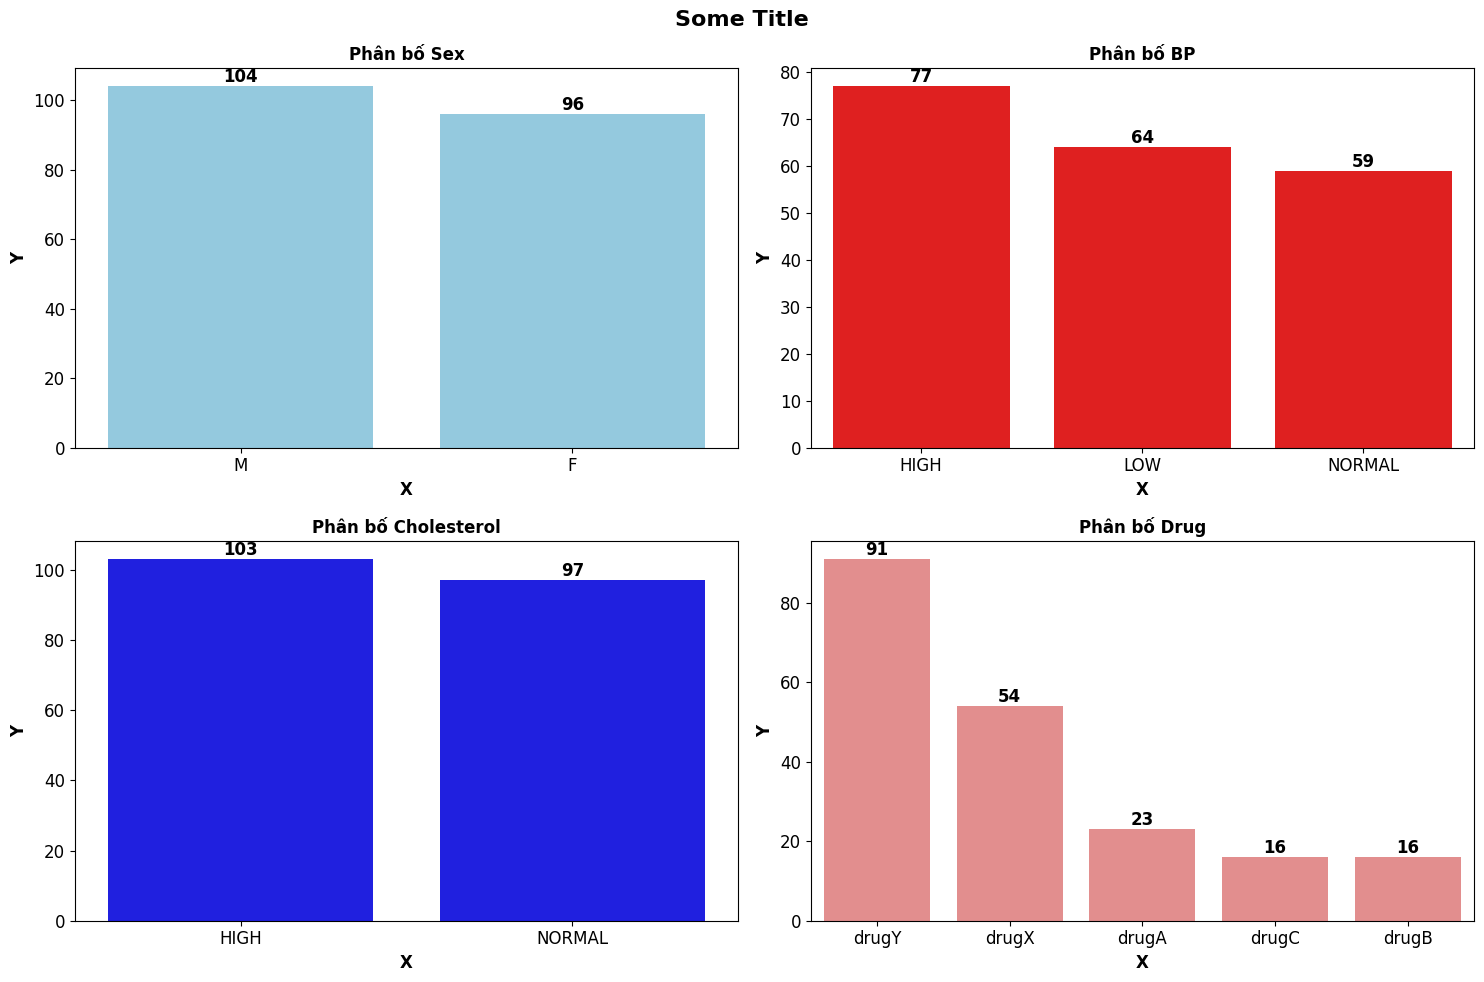


KEY INSIGHTS:
• Giới tính: TODO
• Huyết áp: TODO
• Cholesterol: TODO
• Drug distribution: TODO


In [11]:
# Bước 3.3.1: Phân bố các biến phân loại (Categorical Variables)
# Step 3.3.1: Distribution of Categorical Variables
print("PHÂN TÍCH PHÂN BỐ CÁC BIẾN PHÂN LOẠI")  # Print header / In tiêu đề
print("="*50)                                  # Decorative line / Dòng phân cách

# Tạo subplot cho 4 biến categorical / Create subplots for 4 categorical variables
fig, axes = plt.subplots(2,2,figsize=(15,10))   # TODO: tạo figure và axes (gợi ý: subplots(2,2,figsize=(15,10)))
# Suggestions:
# - plt.subplots(2,2) → 4 subplots
# - figsize=(w,h) → set figure size

fig.suptitle('Some Title', fontsize=16, fontweight='bold')
# TODO: nhập tiêu đề chính cho figure / main title for figure

# Danh sách các biến cần vẽ / List of columns to plot
categorical_cols = ["Sex","BP","Cholesterol","Drug"]   # TODO: liệt kê tên các cột phân loại (ví dụ: ["Sex","BP","Cholesterol","Drug"])
colors = ['skyblue', 'red', 'blue', 'lightcoral']       # TODO: chọn danh sách màu (gợi ý: ['skyblue','lightcoral',...])

# Vẽ từng biểu đồ / Plot each chart
for i, col in enumerate(categorical_cols):
    row, col_idx = i // 2, i % 2
    ax = axes[row, col_idx]

    # Đếm tần suất / Count frequency
    value_counts = my_data[col].value_counts()    # TODO: đếm số lượng các giá trị
    # Suggestions:
    # - value_counts() → count each category
    # - nunique() → number of unique categories (less used here)

    # Vẽ biểu đồ cột / Draw bar chart
    sns.countplot(data=my_data, x=col, ax=ax, color=colors[i], order=value_counts.index)
    # TODO: chọn hàm vẽ (gợi ý: countplot)

    # Thiết lập tiêu đề và labels / Set title and labels
    ax.set_title(f'Phân bố {col}', fontweight='bold', fontsize=12)
    ax.set_xlabel("X", fontweight='bold')   # TODO: gán nhãn trục X / X-axis label
    ax.set_ylabel("Y", fontweight='bold')   # TODO: gán nhãn trục Y / Y-axis label

    # Thêm số liệu trên mỗi cột / Annotate bars with values
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                   (p.get_x() + p.get_width()/2., p.get_height()),
                   ha='center', va='bottom', fontweight='bold')

    # In thống kê summary / Print frequency summary
    print(f"\n{col.upper()}:")
    for category, count in value_counts.items():
        percentage = (count / len(my_data)) * 100
        print(f"  • {category}: {count} bệnh nhân ({percentage:.1f}%)")  # Patients count and percentage

plt.tight_layout()    # TODO: căn chỉnh layout (gợi ý: tight_layout()) / adjust layout
plt.show()    # TODO: hiển thị biểu đồ (gợi ý: show()) / display figure

# Tổng kết insights / Summarize key insights
print(f"\nKEY INSIGHTS:")

print(f"• Giới tính: TODO")
# Gợi ý / Suggestion:
# - Dùng value_counts() để so sánh nam vs nữ / use value_counts() to compare M vs F
# - Điều kiện if … else để in “Cân bằng” hoặc “Không cân bằng” / if-else for "Balanced" or "Unbalanced"

print(f"• Huyết áp: TODO")
# Gợi ý: lấy mode hoặc giá trị tần suất cao nhất / take mode or value_counts().index[0]

print(f"• Cholesterol: TODO")
# Gợi ý: tương tự như trên / same as above

print(f"• Drug distribution: TODO")
# Gợi ý: value_counts().index[0] → loại thuốc phổ biến nhất / most prescribed drug


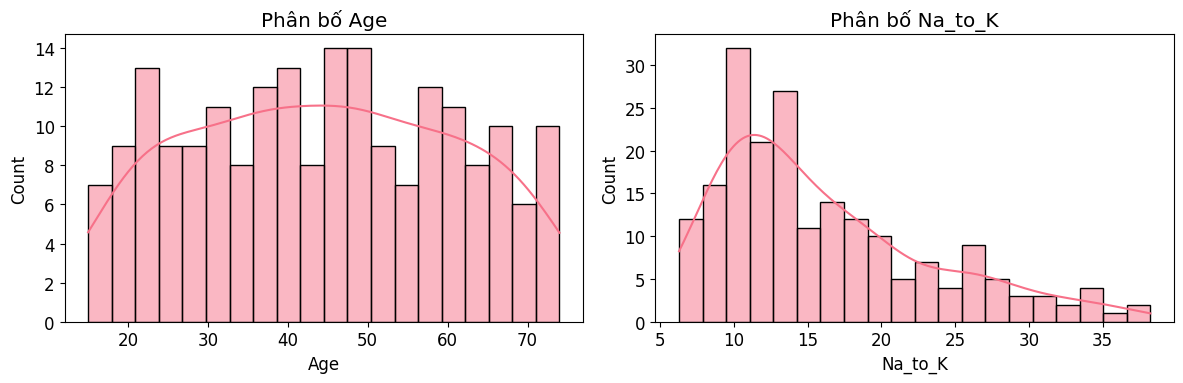

In [12]:
# Phân bố các biến số / Distribution of numeric variables
fig, axes = plt.subplots(1, 2, figsize=(12,4))
# TODO: tạo subplot / create subplots
# Gợi ý / Suggestion: plt.subplots(1, 2, figsize=(12,4)) → 1 hàng, 2 cột, kích thước 12×4
# 1 row, 2 columns, figure size 12×4

# Histogram Age
sns.histplot(my_data["Age"], bins=20, kde=True, ax=axes[0])
# TODO: vẽ biểu đồ histogram / draw histogram
# Gợi ý / Suggestion:
# - dùng histplot / use histplot
# - bins=20 (số khoảng chia dữ liệu / number of bins)
# - kde=True (có đường cong mật độ / with density curve), kde=False (không vẽ đường mật độ / no density curve)
# ax=axes[0]: vẽ vào subplot đầu tiên (bên trái / left subplot)

axes[0].set_title("Phân bố Age")
# TODO: đặt tiêu đề cho biểu đồ / set title
# Gợi ý / Suggestion: set_title("")

# Histogram Na_to_K
sns.histplot(my_data["Na_to_K"], bins=20, kde=True, ax=axes[1])
# TODO: vẽ histogram cho biến Na_to_K / draw histogram for Na_to_K
# Gợi ý / Suggestion:
# - histplot
# - bins=20
# - kde=True hoặc False

axes[1].set_title("Phân bố Na_to_K")
# TODO: đặt tiêu đề cho biểu đồ / set title

plt.tight_layout()
# TODO: căn chỉnh layout / adjust layout
# Gợi ý / Suggestion: tight_layout()

plt.show()
# TODO: hiển thị biểu đồ / display figure
# Gợi ý / Suggestion: show()


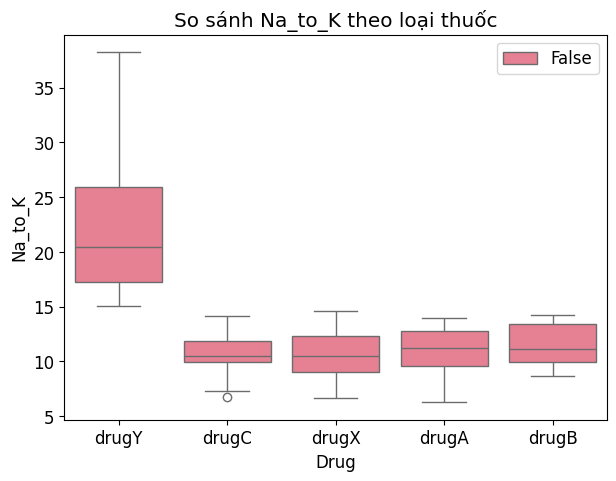

In [15]:
# Boxplot Na_to_K theo loại thuốc / Boxplot of Na_to_K by Drug
plt.figure(figsize=(7,5))
# TODO: tạo figure mới với kích thước 7x5 / create a new figure with size 7x5
# Gợi ý / Suggestion: plt.figure(figsize=(7,5))

sns.boxplot(
    data=my_data,   # TODO: chỉ định dữ liệu / specify the data
    x="Drug",         # TODO: chọn biến phân loại trên trục X (gợi ý: "Drug") / categorical variable for X-axis
    y="Na_to_K",         # TODO: chọn biến số trên trục Y (gợi ý: "Na_to_K") / numeric variable for Y-axis
    hue=False,       # TODO: phân biệt màu theo biến phân loại / color by categorical variable
    palette="husl",   # TODO: bảng màu / color palette (ví dụ: "Set3", "husl", "coolwarm", None)
    legend=True     # TODO: hiển thị legend hay không / show legend (True/False)
)
# Gợi ý / Suggestion:
# - sns.boxplot → vẽ boxplot (phân bố, median, outliers) / plot boxplot showing distribution, median, outliers
# - hue có thể bỏ trống nếu không muốn tách màu / can omit hue if no color separation
# - palette có thể đổi để so sánh (Set2, Dark2, Paired...) / change palette for comparison

plt.title("So sánh Na_to_K theo loại thuốc")
# TODO: đặt tiêu đề / set title (gợi ý: title("..."))

plt.show()
# TODO: hiển thị biểu đồ / display figure (gợi ý: show())


## Kết luận và Gợi ý Mở rộng  
*Conclusion and Suggestions for Extension*

### Tóm tắt những gì đã học  
*Summary of what we learned*

Trong notebook này, chúng ta đã thực hiện **phân tích thăm dò dữ liệu** hoàn chỉnh trên bộ dữ liệu y tế:  
*In this notebook, we performed a complete **exploratory data analysis** on a medical dataset:*

- **Thống kê mô tả**: Hiểu được cấu trúc và đặc điểm cơ bản của 200 bệnh nhân  
  *Descriptive statistics: Understand the basic structure and characteristics of 200 patients*  
- **Kiểm tra chất lượng dữ liệu**: Xác nhận dữ liệu sạch, không có missing values  
  *Data quality check: Confirm clean data with no missing values*  
- **Phân tích đơn biến**: Khám phá phân phối của từng feature  
  *Univariate analysis: Explore the distribution of each feature*  
- **Phân tích đa biến**: Tìm hiểu mối quan hệ giữa features và target  
  *Multivariate analysis: Investigate relationships between features and the target*  
- **Rút ra insight**: Phát hiện những phát hiện quan trọng để hỗ trợ modeling  
  *Insights extraction: Derive key findings to support modeling*

### Key Insights từ phân tích  
*Key insights from the analysis*

**Về dữ liệu / About the data:**  
- Dataset cân bằng tốt với 200 samples, không có missing values  
  *The dataset is well-balanced with 200 samples, no missing values*  
- Mix hợp lý giữa numeric (Age, Na_to_K) và categorical features  
  *Reasonable mix of numeric (Age, Na_to_K) and categorical features*  
- Phân bố Drug khá đều, tạo điều kiện tốt cho classification  
  *Drug distribution is fairly even, providing good conditions for classification*

**Về mối quan hệ / About relationships:**  
- **Na_to_K ratio** có mối liên hệ mạnh với loại thuốc hiệu quả  
  *Na_to_K ratio is strongly associated with the effective drug*  
- **Age và BP** cũng ảnh hưởng đến việc lựa chọn thuốc  
  *Age and BP also affect drug selection*  
- Có patterns rõ ràng giữa patient characteristics và drug response  
  *Clear patterns exist between patient characteristics and drug response*

### Gợi ý Mở rộng và Cải tiến  
*Suggestions for Extension and Improvement*

#### 1. **Deep Dive Khai phá dữ liệu / Advanced EDA**  
```python
# Phân tích correlation nâng cao / Advanced correlation analysis
from scipy.stats import chi2_contingency, pearsonr
# Statistical significance testing / Kiểm định ý nghĩa thống kê
# Feature importance analysis / Phân tích tầm quan trọng của các feature


# BÀI TẬP THỰC HÀNH KHÁM PHÁ DỮ LIỆU TẠI LỚP
*IN-CLASS DATA EXPLORATION PRACTICE EXERCISES*

---

### Bài 1
Đếm số lượng bệnh nhân theo từng loại thuốc trong cột Drug. Thuốc nào có nhiều bệnh nhân nhất?  
*Count the number of patients for each drug in the 'Drug' column. Which drug has the most patients?*

---

### Bài 2
So sánh trung bình chỉ số Na_to_K giữa nhóm bệnh nhân có Cholesterol cao và nhóm có Cholesterol bình thường. Nhóm nào có chỉ số cao hơn?  
*Compare the average Na_to_K ratio between patients with high cholesterol and normal cholesterol. Which group has a higher value?*

---

### Bài 3
Trong từng nhóm huyết áp (BP: LOW, NORMAL, HIGH), hãy xác định loại thuốc nào được kê nhiều nhất. Điều này giúp hiểu xem huyết áp có liên quan đến loại thuốc kê đơn không.  
*For each blood pressure group (BP: LOW, NORMAL, HIGH), identify the drug prescribed most frequently. This helps to understand whether BP is related to prescribed drugs.*

**Gợi ý / Hint:**  
- Dùng `groupby("BP")` để gom nhóm  
  *Use `groupby("BP")` to group the data*  
- Với mỗi nhóm, tìm loại thuốc có tần suất xuất hiện cao nhất: `value_counts().idxmax()`  
  *For each group, find the most frequent drug using `value_counts().idxmax()`*

---

### Bài 4
Hãy lập bảng chéo giữa giới tính (Sex) và loại thuốc (Drug), sau đó tính tỷ lệ % từng loại thuốc trong mỗi giới tính. Nhận xét sự khác biệt giữa nam và nữ.  
*Create a cross-tabulation between Sex and Drug, then calculate the % of each drug per gender. Comment on the differences between male and female.*

**Gợi ý / Hint:**  
- Dùng `pd.crosstab(df["Sex"], df["Drug"])`  
  *Use `pd.crosstab(df["Sex"], df["Drug"])`*  
- Thêm `normalize="index"` để chuyển sang tỷ lệ %  
  *Add `normalize="index"` to convert counts to percentages*  
- So sánh hàng "M" và "F"  
  *Compare the rows "M" and "F"*
